
#Climbing The Steps of The Empire State Building: The Game


The objective is to create a Dice game logic, that will decide the odds of reaching Step 60 of the Empire State Building in 100 rolls. Simulate sequence multiple times to calculate the probability using the Dice game logic.


##Rules
For each random step sequence we throw a Die.
1. Step 0 at ground level, is the starting point.
2. If the roll of the Die returns 1 or 2, climb down one step.
3. If the roll of the Die returns 3, 4 or 5, go up one step.
4. If the roll of the Die returns 6, throw the Die again and advance the number of steps equal to that throw.
5. There is a little chance of being clumsy and falling down the Stairs in which case we start again from 0.
6. The value of Steps cannot be negative, the lowest value would always be 0 (which is the starting point).

##Solution


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Use random.seed() to make results reproducible.

In [2]:
np.random.seed(36)

###Task 1 - Create Dice Game

Use `np.random.rand()` to generate clumsiness as a random number between 0 and 1. If number is less than .001, set steps to 0.

In [3]:
simulations = 10000
runs = []

for i in range(simulations):

  #1 Set ground level to step 0 as the starting point.
  sequence = [0]

  for x in range(100):

    #Grabs last indice in list before rolling again
    step = sequence[-1]

    #Roll die
    dice = np.random.randint(1,7)

    #2a If roll returns 1 or 2
    if dice <= 2:
      #2b Go down one step
      step = max(0, step -1)
    #3a If roll returns 3, 4 or 5
    elif dice <=5:
      #3b Go up one step
      step += 1
    else:
      #4 Roll again and step that amount
      step = step + np.random.randint(1,7)

    #5 Clumsiness
    if np.random.rand() < 0.001:
      #6 Steps cannot be negative
      step = 0

    sequence.append(step)

  runs.append(sequence)

#Convert list to `np.array` and transpose so each column represents one run
np_runs = np.transpose(np.array(runs))

###Task 2 - Estimate Probability

Run Dice Game to calculate the probability

In [4]:
#Select last row (final steps) of simulations
ends = np_runs[-1,:]

#Estimate probability of reaching step 60 in 100 rolls.
probability = np.mean(ends >= 60)
print(f'Estimated probability of reaching step 60: {probability:.2%}')

Estimated probability of reaching step 60: 77.69%


###Task 3 - Create Plot

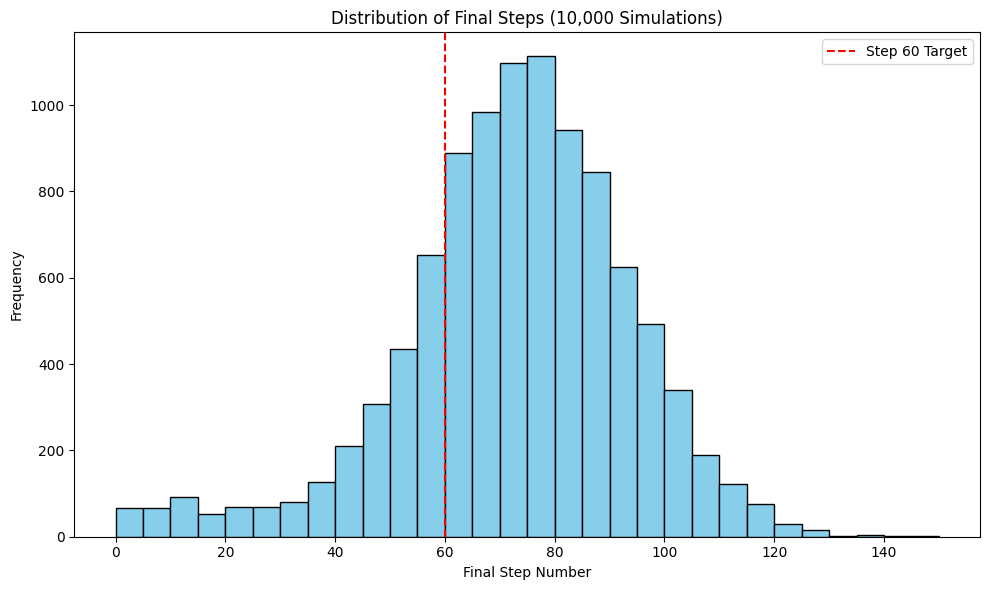

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    ends,
    bins=30,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribution of Final Steps (10,000 Simulations)')
plt.xlabel('Final Step Number')
plt.ylabel('Frequency')

plt.axvline(
    x=60,
    color='red',
    linestyle='--',
    label='Step 60 Target'
)

plt.legend()

plt.tight_layout()

plt.show()